In [2]:
#Task 1: Data Preprocessing and Model Training
import os
import sys
import platform
import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame.copy()
df = df.replace("?", np.nan)

df["target"] = df["class"].map({"<=50K": 0, ">50K": 1}).astype(int)
df = df.drop(columns=["class"])

def create_engineered_features(data):
    data = data.copy()
    data["age_bucket"] = pd.cut(data["age"], bins=[0, 25, 35, 45, 55, 65, np.inf], labels=["Young", "Early_Career", "Mid_Career", "Experienced", "Senior", "Older"])
    data["hours_bucket"] = pd.cut(data["hours-per-week"], bins=[0, 30, 40, 50, 60, np.inf], labels=["Part_Time", "Standard", "Overtime", "High_Hours", "Very_High_Hours"])
    data["capital_gain_flag"] = (data["capital-gain"] > 0).astype(int)
    data["log_capital_gain"] = np.log1p(data["capital-gain"])
    data["higher_education"] = (data["education-num"] >= 13).astype(int)
    data["education_hours_interaction"] = data["education-num"] * data["hours-per-week"]
    data["capital_loss_flag"] = (data["capital-loss"] > 0).astype(int)
    data["age_hours_interaction"] = data["age"] * data["hours-per-week"]
    return data

X = df.drop(columns=["target"])
y = df["target"]

numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week", "capital_gain_flag", "log_capital_gain", "higher_education", "education_hours_interaction", "capital_loss_flag", "age_hours_interaction"]
categorical_features = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country", "age_bucket", "hours_bucket"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

logistic_pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(create_engineered_features, validate=False)),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE))
])
random_forest_pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(create_engineered_features, validate=False)),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
logistic_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)
random_forest_predictions = random_forest_pipeline.predict(X_test)
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Test Accuracy": [accuracy_score(y_test, logistic_predictions), accuracy_score(y_test, random_forest_predictions)]
})
display(results)

joblib.dump(logistic_pipeline, os.path.join(OUTPUT_DIR, "logistic_pipeline.joblib"))
joblib.dump(random_forest_pipeline, os.path.join(OUTPUT_DIR, "random_forest_pipeline.joblib"))

version_info = pd.DataFrame({
    "Component": ["Python", "Platform", "NumPy", "Pandas", "Scikit-learn", "Joblib"],
    "Version": [sys.version, platform.platform(), np.__version__, pd.__version__, sklearn.__version__, joblib.__version__]
})
version_info.to_csv(os.path.join(OUTPUT_DIR, "library_versions.csv"), index=False)

loaded_logistic = joblib.load(os.path.join(OUTPUT_DIR, "logistic_pipeline.joblib"))
loaded_random_forest = joblib.load(os.path.join(OUTPUT_DIR, "random_forest_pipeline.joblib"))
print("Logistic reload verification:", np.array_equal(logistic_pipeline.predict(X_test), loaded_logistic.predict(X_test)))
print("Random Forest reload verification:", np.array_equal(random_forest_pipeline.predict(X_test), loaded_random_forest.predict(X_test)))
print("Saved files:")
print("logistic_pipeline.joblib")
print("random_forest_pipeline.joblib")
print("library_versions.csv")

,Model,Test Accuracy
0,Logistic Regression,0.859760
1,Random Forest,0.851981


Logistic reload verification: True
Random Forest reload verification: True
Saved files:
logistic_pipeline.joblib
random_forest_pipeline.joblib
library_versions.csv


In [4]:
# Task2 
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from scipy.stats import loguniform, randint

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

logistic_params = {
    "model__C": loguniform(0.001, 100),
    "model__l1_ratio": [0, 1]
}

random_forest_params = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [None, 5, 10, 15, 20, 30, 40],
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": ["sqrt", "log2", 0.5, 0.75]
}

logistic_pipeline.set_params(
    model__solver="saga",
    model__penalty="elasticnet"
)

logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Tuning Logistic Regression...")
logistic_search.fit(X_train, y_train)

print("\nTuning Random Forest...")
random_forest_search.fit(X_train, y_train)

best_logistic_model = logistic_search.best_estimator_
best_random_forest_model = random_forest_search.best_estimator_

logistic_test_predictions = best_logistic_model.predict(X_test)
random_forest_test_predictions = best_random_forest_model.predict(X_test)

logistic_test_f1 = f1_score(y_test, logistic_test_predictions)
random_forest_test_f1 = f1_score(y_test, random_forest_test_predictions)

logistic_test_accuracy = accuracy_score(y_test, logistic_test_predictions)
random_forest_test_accuracy = accuracy_score(y_test, random_forest_test_predictions)

print("\nLOGISTIC REGRESSION")
print("Best CV F1:", logistic_search.best_score_)
print("Best Parameters:", logistic_search.best_params_)
print("Test F1:", logistic_test_f1)
print("Test Accuracy:", logistic_test_accuracy)

print("\nRANDOM FOREST")
print("Best CV F1:", random_forest_search.best_score_)
print("Best Parameters:", random_forest_search.best_params_)
print("Test F1:", random_forest_test_f1)
print("Test Accuracy:", random_forest_test_accuracy)

task2_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Best CV F1": [
        logistic_search.best_score_,
        random_forest_search.best_score_
    ],
    "Test F1": [
        logistic_test_f1,
        random_forest_test_f1
    ],
    "Test Accuracy": [
        logistic_test_accuracy,
        random_forest_test_accuracy
    ]
})

display(task2_results)

joblib.dump(
    best_logistic_model,
    os.path.join(OUTPUT_DIR, "best_logistic_pipeline.joblib")
)

joblib.dump(
    best_random_forest_model,
    os.path.join(OUTPUT_DIR, "best_random_forest_pipeline.joblib")
)


Tuning Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

LOGISTIC REGRESSION
Best CV F1: 0.6745280279960943
Best Parameters: {'model__C': np.float64(73.92266140516048), 'model__l1_ratio': 0}
Test F1: 0.6744020838266636
Test Accuracy: 0.8592486436687481

RANDOM FOREST
Best CV F1: 0.6838025483331801
Best Parameters: {'model__max_depth': 15, 'model__max_features': 0.5, 'model__min_samples_leaf': 7, 'model__n_estimators': 363}
Test F1: 0.6906302420321112
Test Accuracy: 0.8678472719828028


,Model,Best CV F1,Test F1,Test Accuracy
0,Logistic Regression,0.674528,0.674402,0.859249
1,Random Forest,0.683803,0.690630,0.867847


['../outputs\\best_random_forest_pipeline.joblib']

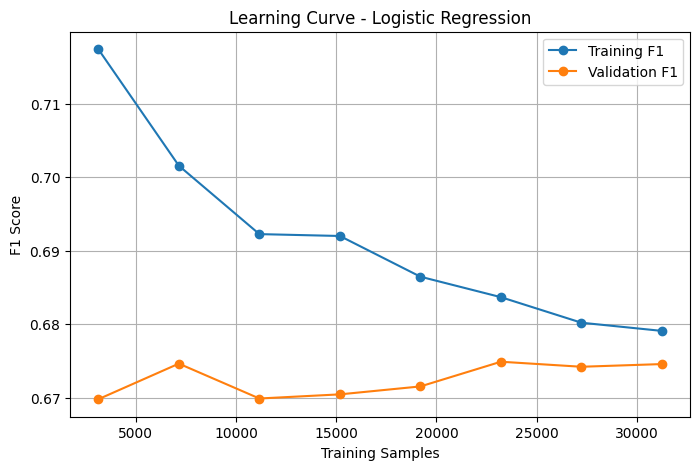

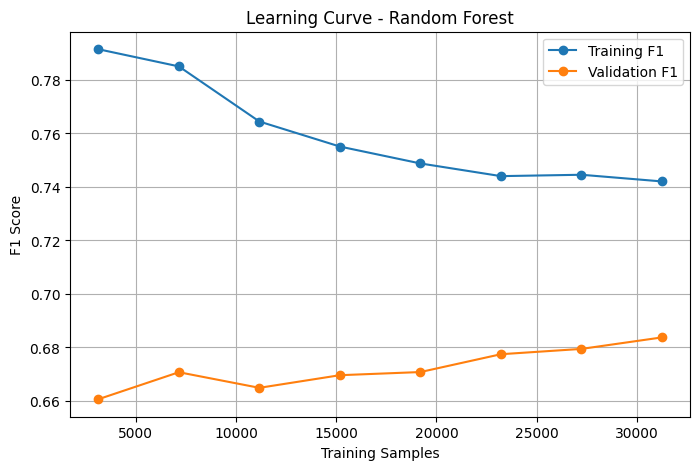

,Model,Training Size,Training F1,Validation F1
0,Logistic Regression,3125,0.717396,0.669785
1,Logistic Regression,7144,0.701550,0.674627
2,Logistic Regression,11163,0.692245,0.669883
3,Logistic Regression,15182,0.691991,0.670446
4,Logistic Regression,19201,0.686452,0.671526
5,Logistic Regression,23220,0.683666,0.674886
6,Logistic Regression,27239,0.680192,0.674201
7,Logistic Regression,31258,0.679078,0.674567
8,Random Forest,3125,0.791477,0.660657
9,Random Forest,7144,0.785054,0.670750


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,C,CV F1
0,0.001,0.601182
1,0.010,0.652074
2,0.100,0.670460
3,1.000,0.673409
4,10.000,0.674300
5,100.000,0.674528


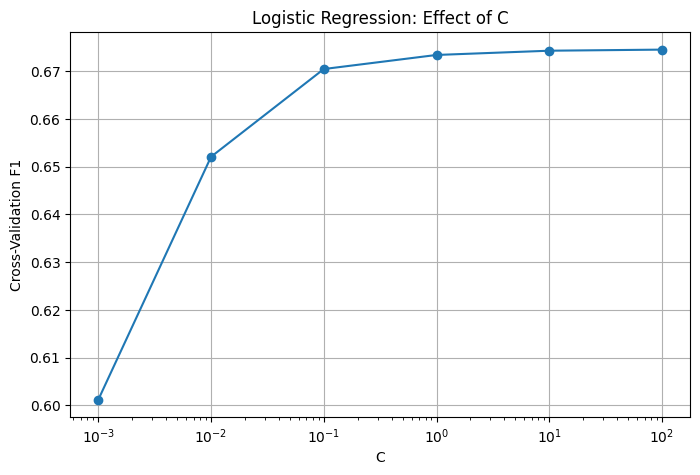

Best C based on cross-validation: 100.0

Task 3 completed successfully.

Diagnosis:
If training F1 is much higher than validation F1, the model is overfitting.
If both training and validation F1 are low, the model is underfitting.
For Logistic Regression, regularization can be controlled using C.
Lower C means stronger regularization and higher C means weaker regularization.
For Random Forest, overfitting can be reduced using smaller max_depth or larger min_samples_leaf.


In [5]:
# Task 3: Learning Curves and Regularization Analysis
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import f1_score

RANDOM_STATE = 42
OUTPUT_DIR = "../outputs"

best_logistic_model = joblib.load(
    os.path.join(OUTPUT_DIR, "best_logistic_pipeline.joblib")
)

best_random_forest_model = joblib.load(
    os.path.join(OUTPUT_DIR, "best_random_forest_pipeline.joblib")
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

models = {
    "Logistic Regression": best_logistic_model,
    "Random Forest": best_random_forest_model
}

train_sizes = np.linspace(0.1, 1.0, 8)
learning_curve_results = []

for name, model in models.items():
    sizes, train_scores, validation_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        train_sizes=train_sizes,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    for size, train_score, validation_score in zip(
        sizes, train_mean, validation_mean
    ):
        learning_curve_results.append({
            "Model": name,
            "Training Size": size,
            "Training F1": train_score,
            "Validation F1": validation_score
        })

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_mean, marker="o", label="Training F1")
    plt.plot(sizes, validation_mean, marker="o", label="Validation F1")
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training Samples")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

learning_curve_df = pd.DataFrame(learning_curve_results)
display(learning_curve_df)

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
C_results = []

for C in C_values:
    model = clone(best_logistic_model)
    model.set_params(model__C=C)

    scores = []

    for train_index, val_index in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_index]
        X_val = X_train.iloc[val_index]
        y_tr = y_train.iloc[train_index]
        y_val = y_train.iloc[val_index]

        model.fit(X_tr, y_tr)

        val_predictions = model.predict(X_val)

        scores.append(
            f1_score(y_val, val_predictions)
        )

    C_results.append({
        "C": C,
        "CV F1": np.mean(scores)
    })

C_results_df = pd.DataFrame(C_results)

display(C_results_df)

plt.figure(figsize=(8, 5))
plt.semilogx(
    C_results_df["C"],
    C_results_df["CV F1"],
    marker="o"
)
plt.title("Logistic Regression: Effect of C")
plt.xlabel("C")
plt.ylabel("Cross-Validation F1")
plt.grid(True)
plt.show()

best_C = C_results_df.loc[
    C_results_df["CV F1"].idxmax(),
    "C"
]

print("Best C based on cross-validation:", best_C)

print("\nTask 3 completed successfully.")

print("\nDiagnosis:")
print("If training F1 is much higher than validation F1, the model is overfitting.")
print("If both training and validation F1 are low, the model is underfitting.")
print("For Logistic Regression, regularization can be controlled using C.")
print("Lower C means stronger regularization and higher C means weaker regularization.")
print("For Random Forest, overfitting can be reduced using smaller max_depth or larger min_samples_leaf.")

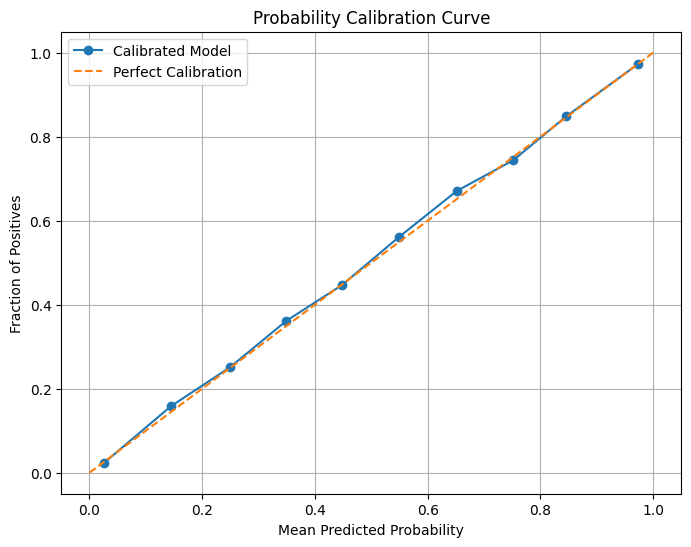

Brier Score: 0.0975


,Threshold,F1,Precision,Recall
24,0.34,0.699790,0.643537,0.766820
25,0.35,0.698874,0.649289,0.756658
23,0.33,0.698163,0.635510,0.774521
26,0.36,0.697544,0.655111,0.745855
22,0.32,0.696882,0.627917,0.782864
27,0.37,0.696796,0.661287,0.736335
30,0.40,0.696501,0.683484,0.710022
28,0.38,0.696311,0.668174,0.726923
20,0.30,0.696044,0.615000,0.801690
21,0.31,0.695894,0.621075,0.791208


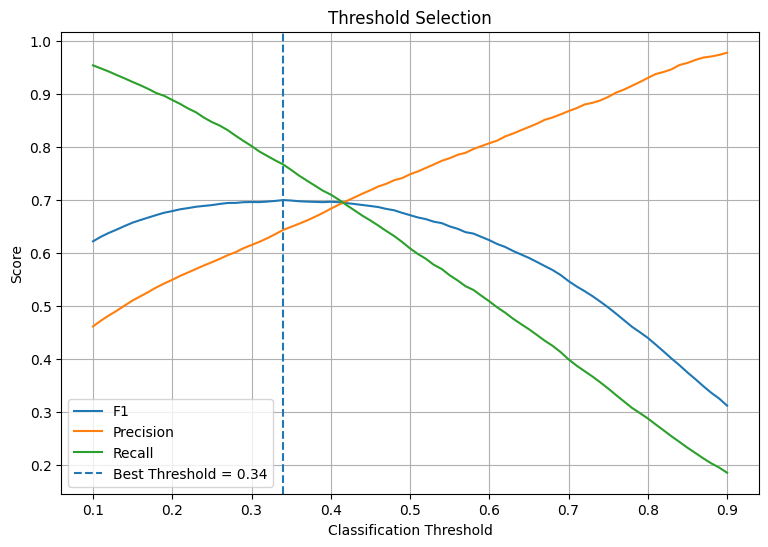

,Metric,Threshold 0.50,Threshold 0.34
0,F1,0.673639,0.705511
1,Precision,0.758159,0.655413
2,Recall,0.606074,0.763901
3,Accuracy,0.859453,0.847374


Default Threshold Confusion Matrix:
[[6979  452]
 [ 921 1417]]

Tuned Threshold Confusion Matrix:
[[6492  939]
 [ 552 1786]]

Best Threshold: 0.34
Best Training OOF F1: 0.6998
Test Brier Score: 0.0975

Model saving failed: Can't pickle <function create_engineered_features at 0x0000020BF1695F30>: it's not the same object as __main__.create_engineered_features
Calibration and threshold selection completed successfully.


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

RANDOM_STATE = 42
OUTPUT_DIR = "../outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

best_logistic_model = joblib.load(
    os.path.join(OUTPUT_DIR, "best_logistic_pipeline.joblib")
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

final_model = best_logistic_model

calibrated_model = CalibratedClassifierCV(
    estimator=final_model,
    method="sigmoid",
    cv=5,
    n_jobs=-1
)

calibrated_model.fit(X_train, y_train)

test_probabilities = calibrated_model.predict_proba(X_test)[:, 1]

brier_score = brier_score_loss(
    y_test,
    test_probabilities
)

prob_true, prob_pred = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Calibrated Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Probability Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Brier Score:", round(brier_score, 4))

oof_probabilities = cross_val_predict(
    calibrated_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "F1": f1_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "Precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = float(
    best_threshold_row["Threshold"]
)

display(
    threshold_results
    .sort_values("F1", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Selection")
plt.legend()
plt.grid(True)
plt.show()

default_predictions = (
    test_probabilities >= 0.50
).astype(int)

tuned_predictions = (
    test_probabilities >= best_threshold
).astype(int)

default_cm = confusion_matrix(
    y_test,
    default_predictions
)

tuned_cm = confusion_matrix(
    y_test,
    tuned_predictions
)

threshold_comparison = pd.DataFrame({
    "Metric": [
        "F1",
        "Precision",
        "Recall",
        "Accuracy"
    ],
    "Threshold 0.50": [
        f1_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        accuracy_score(
            y_test,
            default_predictions
        )
    ],
    f"Threshold {best_threshold:.2f}": [
        f1_score(
            y_test,
            tuned_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            tuned_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            tuned_predictions,
            zero_division=0
        ),
        accuracy_score(
            y_test,
            tuned_predictions
        )
    ]
})

display(threshold_comparison)

print("Default Threshold Confusion Matrix:")
print(default_cm)

print("\nTuned Threshold Confusion Matrix:")
print(tuned_cm)

print("\nBest Threshold:", round(best_threshold, 2))
print(
    "Best Training OOF F1:",
    round(float(best_threshold_row["F1"]), 4)
)
print(
    "Test Brier Score:",
    round(float(brier_score), 4)
)

final_artifact = {
    "model": calibrated_model,
    "threshold": best_threshold,
    "brier_score": float(brier_score)
}

final_model_path = os.path.join(
    OUTPUT_DIR,
    "final_calibrated_model.joblib"
)

try:
    joblib.dump(
        final_artifact,
        final_model_path
    )
    print("Saved:", final_model_path)

except Exception as e:
    print("\nModel saving failed:", e)
    print("Calibration and threshold selection completed successfully.")

In [16]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

class AdultFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()

        data["age_bucket"] = pd.cut(
            data["age"],
            bins=[0, 25, 35, 45, 55, 65, np.inf],
            labels=[
                "Young",
                "Early_Career",
                "Mid_Career",
                "Experienced",
                "Senior",
                "Older"
            ]
        )

        data["hours_bucket"] = pd.cut(
            data["hours-per-week"],
            bins=[0, 30, 40, 50, 60, np.inf],
            labels=[
                "Part_Time",
                "Standard",
                "Overtime",
                "High_Hours",
                "Very_High_Hours"
            ]
        )

        data["capital_gain_flag"] = (
            data["capital-gain"] > 0
        ).astype(int)

        data["log_capital_gain"] = np.log1p(
            data["capital-gain"]
        )

        data["higher_education"] = (
            data["education-num"] >= 13
        ).astype(int)

        data["education_hours_interaction"] = (
            data["education-num"] *
            data["hours-per-week"]
        )

        data["capital_loss_flag"] = (
            data["capital-loss"] > 0
        ).astype(int)

        data["age_hours_interaction"] = (
            data["age"] *
            data["hours-per-week"]
        )

        return data


numeric_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "education_hours_interaction",
    "capital_loss_flag",
    "age_hours_interaction"
]

categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "age_bucket",
    "hours_bucket"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

clean_logistic_pipeline = Pipeline([
    ("feature_engineering", AdultFeatureEngineer()),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        l1_ratio=1,
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

clean_logistic_pipeline.fit(X_train, y_train)

clean_calibrated_model = CalibratedClassifierCV(
    estimator=clean_logistic_pipeline,
    method="sigmoid",
    cv=5,
    n_jobs=-1
)

clean_calibrated_model.fit(X_train, y_train)

test_probabilities = clean_calibrated_model.predict_proba(X_test)[:, 1]

best_threshold = 0.50

test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

accuracy = accuracy_score(y_test, test_predictions)
precision = precision_score(y_test, test_predictions)
recall = recall_score(y_test, test_predictions)
f1 = f1_score(y_test, test_predictions)
roc_auc = roc_auc_score(y_test, test_probabilities)
brier = brier_score_loss(y_test, test_probabilities)

print("FINAL TEST RESULTS")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Brier    : {brier:.4f}")
print(f"Threshold: {best_threshold:.2f}")

print("\nCONFUSION MATRIX")
print("=" * 50)
print(confusion_matrix(y_test, test_predictions))

print("\nCLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(
    y_test,
    test_predictions,
    target_names=["<=50K", ">50K"]
))

final_artifact = {
    "model": clean_calibrated_model,
    "threshold": float(best_threshold),
    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "brier_score": float(brier)
    },
    "random_state": RANDOM_STATE
}

final_model_path = os.path.join(
    OUTPUT_DIR,
    "final_adult_income_pipeline.joblib"
)

joblib.dump(
    final_artifact,
    final_model_path
)

print("\nMODEL SAVED")
print("=" * 50)
print(final_model_path)

loaded_artifact = joblib.load(final_model_path)

print("\nRELOAD VERIFICATION")
print("=" * 50)
print("Model successfully reloaded:", loaded_artifact["model"] is not None)
print("Saved threshold:", loaded_artifact["threshold"])
print("Saved F1:", loaded_artifact["metrics"]["f1"])

sample_probabilities = loaded_artifact["model"].predict_proba(
    X_test.iloc[:5]
)[:, 1]

sample_predictions = (
    sample_probabilities >= loaded_artifact["threshold"]
).astype(int)

print("\nINFERENCE TEST")
print("=" * 50)
print("Probabilities:", sample_probabilities)
print("Predictions:", sample_predictions)

c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


FINAL TEST RESULTS
Accuracy : 0.8597
Precision: 0.7584
Recall   : 0.6069
F1 Score : 0.6743
ROC-AUC  : 0.9139
Brier    : 0.0974
Threshold: 0.50

CONFUSION MATRIX
[[6979  452]
 [ 919 1419]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.76      0.61      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769


MODEL SAVED
../outputs\final_adult_income_pipeline.joblib

RELOAD VERIFICATION
Model successfully reloaded: True
Saved threshold: 0.5
Saved F1: 0.6742694226657163

INFERENCE TEST
Probabilities: [0.22146695 0.00385985 0.67672415 0.07458315 0.60893655]
Predictions: [0 0 1 0 1]
